<div style="padding:20px;color:white;font-size:30px;font-family:Georgia;
text-align:center;border-radius:10px;background:#2E86C1;">
<b>🎓 Student Health Risk Prediction 🩺</b>
</div>

<h3 align="center" style="font-size: 35px; color: #800080; font-family: Georgia;">
    <span style="color: #008080;"> Author:</span> 
    <span style="color: black;">AGRIM AGARWAL .📄🖋️</span>
</h3>

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT7xMGsoO2iVzZssLtTPOQkuHKbz3MUWcmEmidUjsGNLg&s=10" style='width: 1000px; height: 450px;'>

In [443]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score
from sklearn.ensemble import StackingClassifier
from imblearn.under_sampling import RandomUnderSampler
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer

In [444]:
##load dataset
train=pd.read_csv(r"C:\Users\hp\Downloads\train2.csv")
test=pd.read_csv(r"C:\Users\hp\Downloads\test2.csv")

In [446]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [447]:
test.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [448]:
train.shape

(690088, 15)

In [449]:
test.shape

(295753, 14)

In [450]:
train.isnull().sum().to_frame().rename(columns={0:"null_value"})

,null_value
id,0
health_condition,0
sleep_duration,75999
heart_rate,7833
bmi,13898
calorie_expenditure,52853
step_count,13916
exercise_duration,6901
water_intake,43477
diet_type,6901


In [451]:
test.isnull().sum().to_frame().rename(columns={0:"null_value"})

,null_value
id,0
sleep_duration,32571
heart_rate,3357
bmi,5956
calorie_expenditure,22652
step_count,5964
exercise_duration,2958
water_intake,18633
diet_type,2958
stress_level,35490


In [452]:
train_null = train.isnull().sum().rename("null_value").to_frame()


train_null["null_percentage"] = round((train.isnull().sum() / train.shape[0]) * 100,0)
print(train_null)


                         null_value  null_percentage
id                                0              0.0
health_condition                  0              0.0
sleep_duration                75999             11.0
heart_rate                     7833              1.0
bmi                           13898              2.0
calorie_expenditure           52853              8.0
step_count                    13916              2.0
exercise_duration              6901              1.0
water_intake                  43477              6.0
diet_type                      6901              1.0
stress_level                  82811             12.0
sleep_quality                 58331              8.0
physical_activity_level       36621              5.0
smoking_alcohol               28582              4.0
gender                        21373              3.0


In [453]:
test_null=test.isnull().sum().rename("null_value").to_frame()
test_null["null_percentage"]=round((test.isnull().sum()/test.shape[0])*100,0)
print(test_null)

                         null_value  null_percentage
id                                0              0.0
sleep_duration                32571             11.0
heart_rate                     3357              1.0
bmi                            5956              2.0
calorie_expenditure           22652              8.0
step_count                     5964              2.0
exercise_duration              2958              1.0
water_intake                  18633              6.0
diet_type                      2958              1.0
stress_level                  35490             12.0
sleep_quality                 24999              8.0
physical_activity_level       15695              5.0
smoking_alcohol               12249              4.0
gender                         9160              3.0


In [454]:
col_str=train.select_dtypes(include=["string","object"]).columns.to_list()
print(col_str)

['health_condition', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [455]:
for data in col_str:
  train[data].fillna(train[data].mode()[0],inplace=True)
  if data !="health_condition":
    test[data].fillna(test[data].mode()[0],inplace=True)

In [456]:
print(test.isnull().sum())

id                             0
sleep_duration             32571
heart_rate                  3357
bmi                         5956
calorie_expenditure        22652
step_count                  5964
exercise_duration           2958
water_intake               18633
diet_type                      0
stress_level                   0
sleep_quality                  0
physical_activity_level        0
smoking_alcohol                0
gender                         0
dtype: int64


In [457]:
col_num=train.select_dtypes(include=["int","float"]).columns.to_list()
for data in col_num:
  train[data].fillna(train[data].median(),inplace=True)
  test[data].fillna(test[data].median(),inplace=True)

In [458]:
print(train.isnull().sum())

id                         0
health_condition           0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64


In [459]:
print("train_duplicated :",train.duplicated().sum())
print("test_duplicated :",test.duplicated().sum())

train_duplicated : 0
test_duplicated : 0


In [460]:
num_cols = train.select_dtypes(include=np.number).columns
cat_cols = train.select_dtypes(include="object").columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake'],
      dtype='object')
Categorical Columns: Index(['health_condition', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')


In [461]:
train["health_condition"].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

In [462]:
train["sleep_quality"].unique()

array(['average', 'poor', 'good'], dtype=object)

In [367]:
##EDA

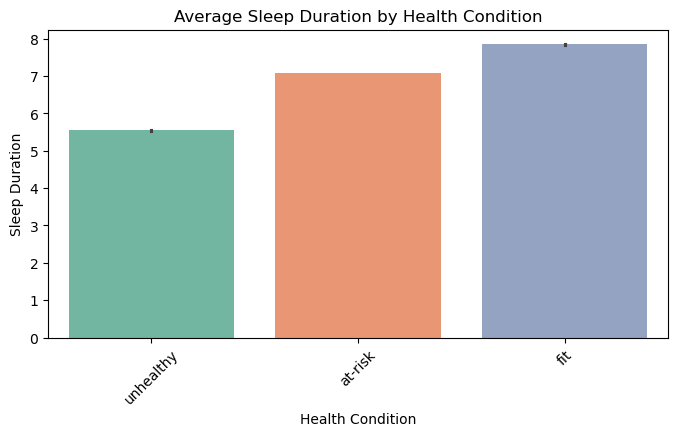

In [368]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=train,
    x="health_condition",
    y="sleep_duration",
    palette="Set2"
)

plt.title("Average Sleep Duration by Health Condition")
plt.xlabel("Health Condition")
plt.ylabel("Sleep Duration")
plt.xticks(rotation=45)
plt.show()

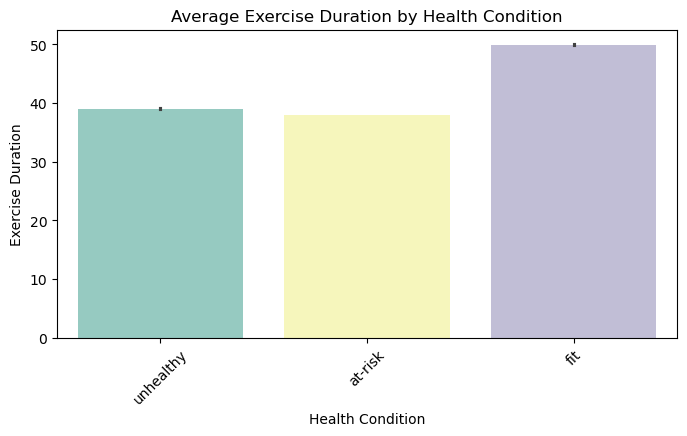

In [369]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=train,
    x="health_condition",
    y="exercise_duration",
    palette="Set3"
)

plt.title("Average Exercise Duration by Health Condition")
plt.xlabel("Health Condition")
plt.ylabel("Exercise Duration")
plt.xticks(rotation=45)
plt.show()

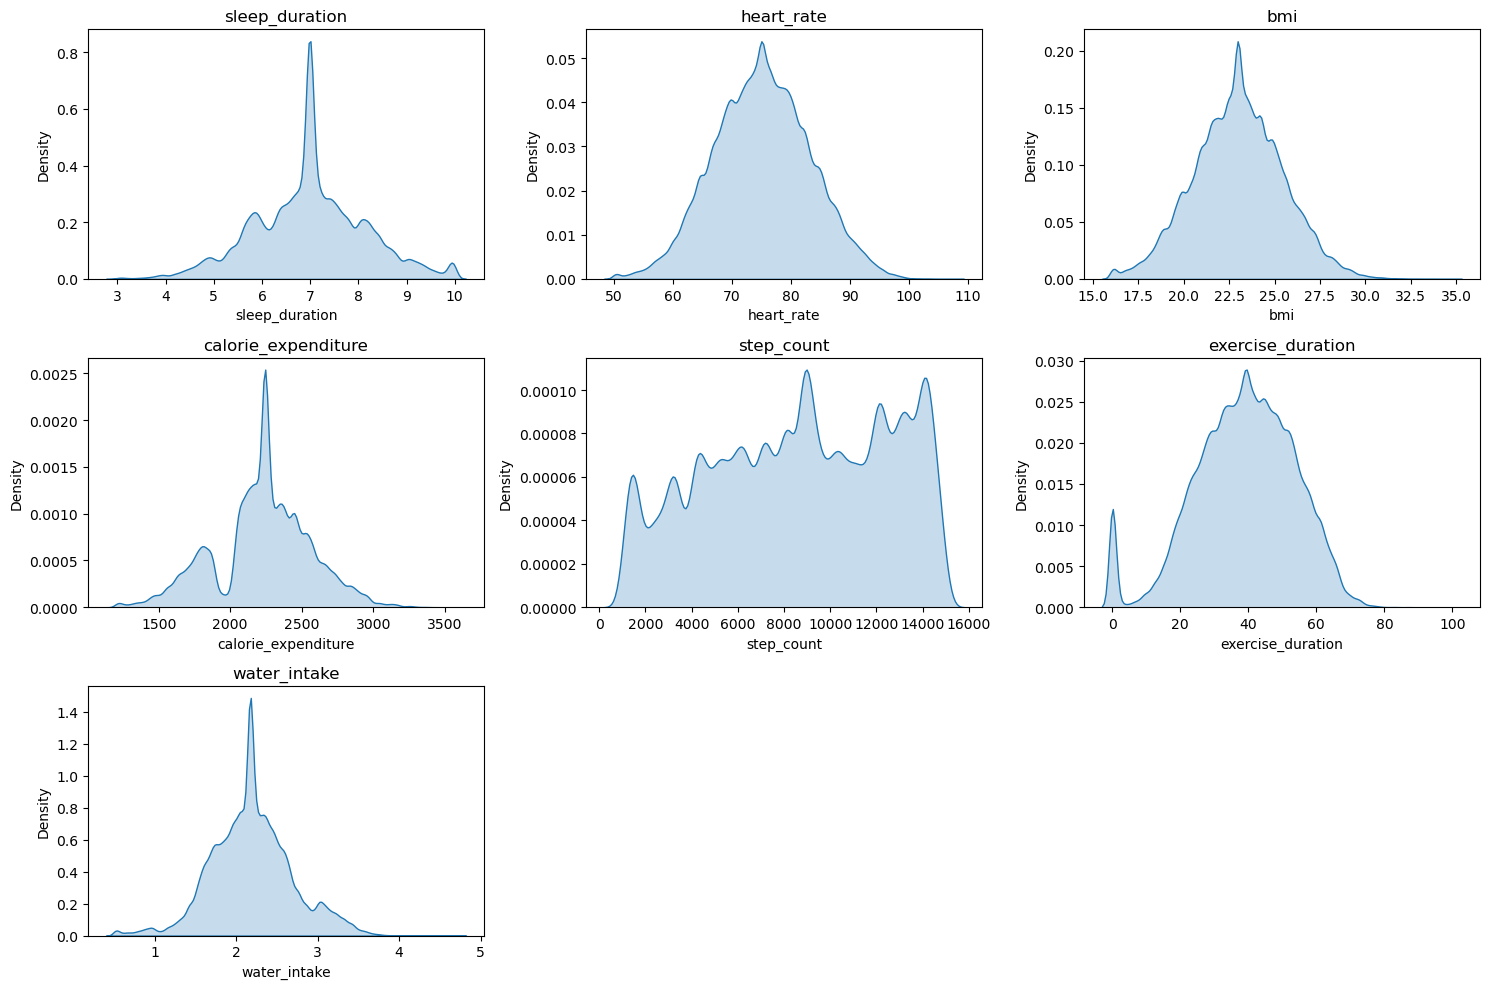

In [370]:
##train data distribution in each columns
plt.figure(figsize=(15, 10))

n = 1
for col in num_cols:
    if col != "id":
        plt.subplot(3, 3, n)
        sns.kdeplot(train[col], fill=True)
        plt.title(col)
        n += 1

plt.tight_layout()
plt.show()

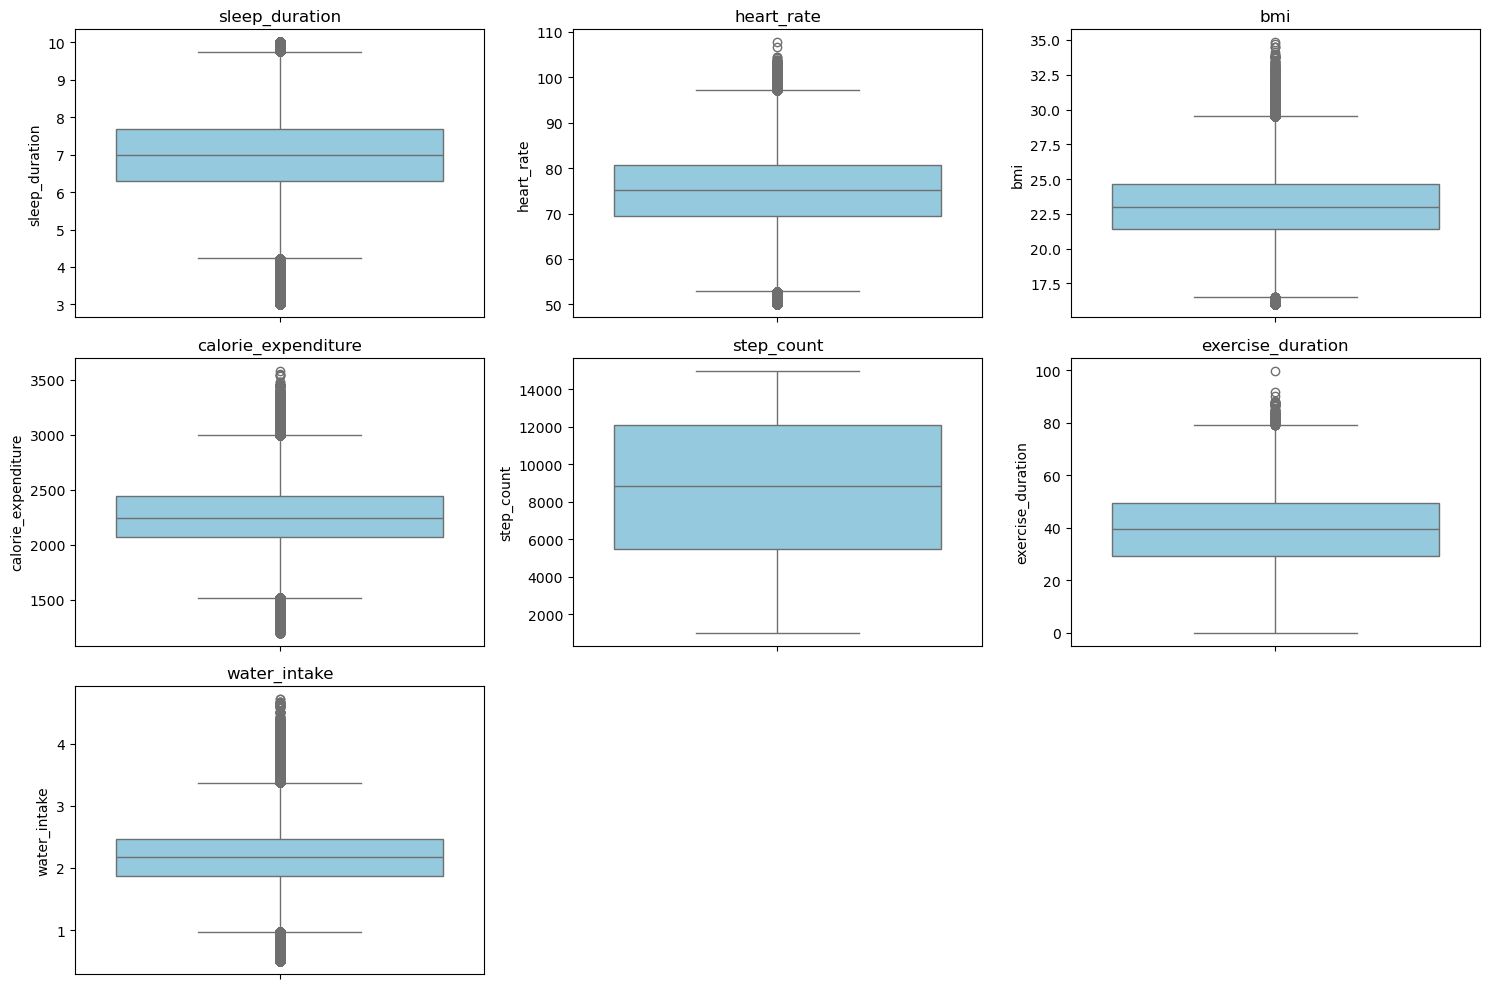

In [371]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols[1:],1):
    plt.subplot(3,3,i)
    sns.boxplot(y=train[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

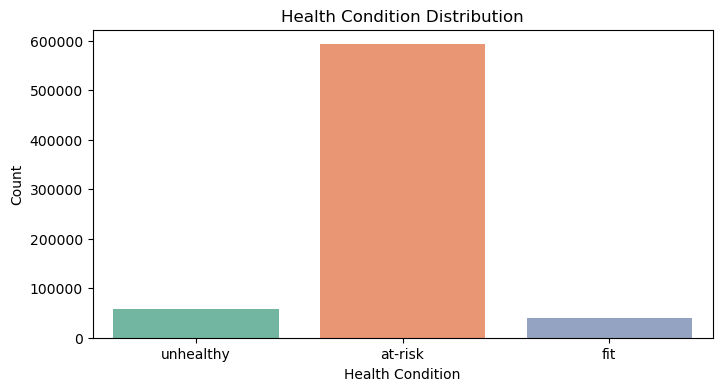

In [372]:
plt.figure(figsize=(8,4))
sns.countplot(x="health_condition", data=train, palette="Set2")
plt.title("Health Condition Distribution")
plt.xlabel("Health Condition")
plt.ylabel("Count")
plt.show()

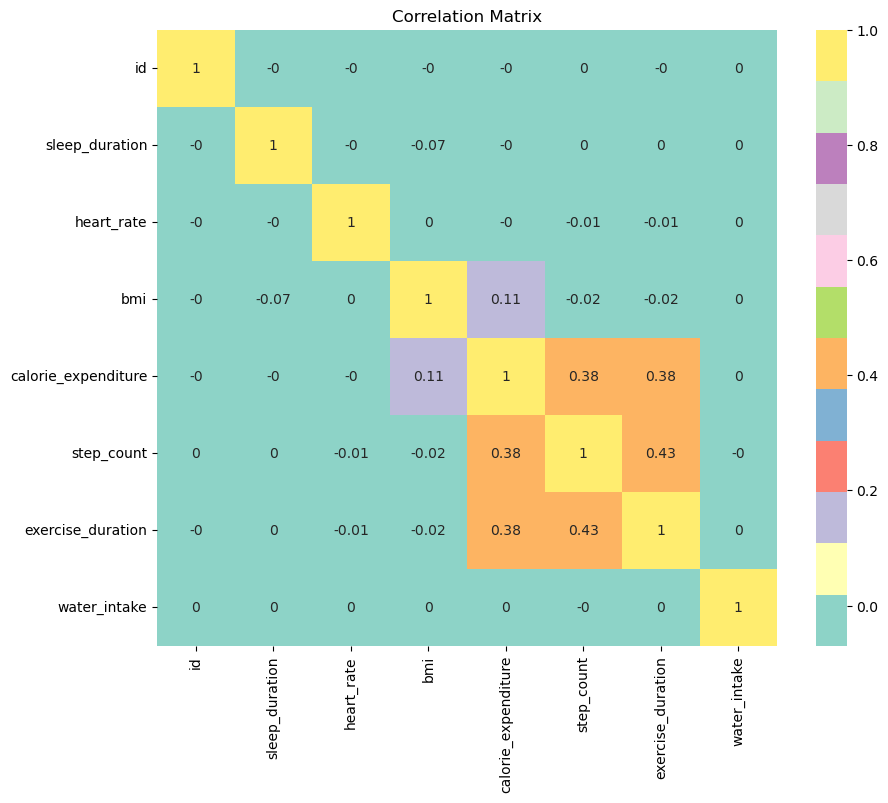

In [373]:
plt.figure(figsize=(10,8))
sns.heatmap(round(train[num_cols].corr(),2),
            annot=True,
            cmap="Set3")

plt.title("Correlation Matrix")
plt.show()

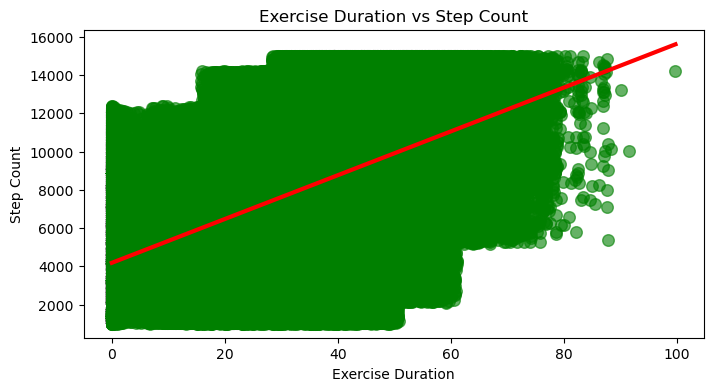

In [374]:
##exercise_duration vs step_count
plt.figure(figsize=(8,4))

sns.regplot(
    data=train,
    x="exercise_duration",
    y="step_count",
    line_kws={"color":"red","lw":3},
    scatter_kws={"alpha":0.6,"color":"green","s":70}
)

plt.title("Exercise Duration vs Step Count")
plt.xlabel("Exercise Duration")
plt.ylabel("Step Count")
plt.show()

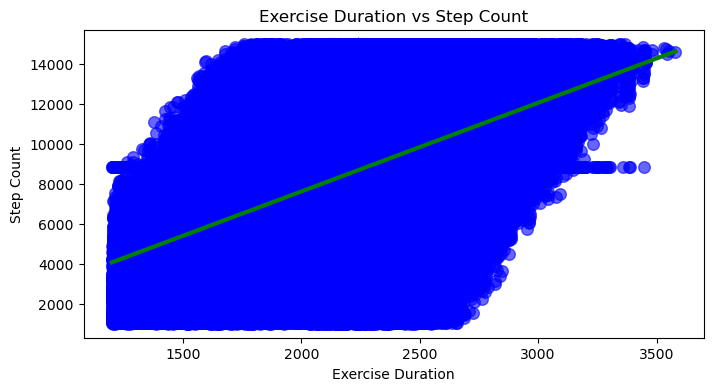

In [375]:
##calories_expenditure vs step_count
plt.figure(figsize=(8,4))

sns.regplot(
    data=train,
    x="calorie_expenditure",
    y="step_count",
    line_kws={"color":"green","lw":3},
    scatter_kws={"alpha":0.6,"color":"blue","s":70}
)

plt.title("Exercise Duration vs Step Count")
plt.xlabel("Exercise Duration")
plt.ylabel("Step Count")
plt.show()

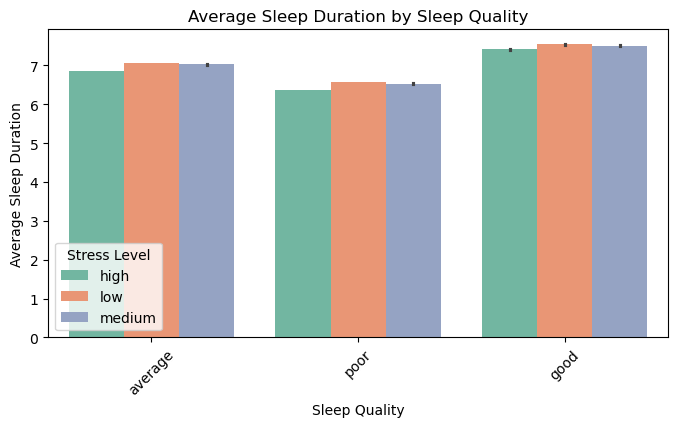

In [376]:
#sleep quality vs sleep duration
plt.figure(figsize=(8,4))

sns.barplot(
    data=train,
    x="sleep_quality",
    y="sleep_duration",
    hue="stress_level",
    palette="Set2"
)

plt.title("Average Sleep Duration by Sleep Quality")
plt.xlabel("Sleep Quality")
plt.ylabel("Average Sleep Duration")
plt.xticks(rotation=45)
plt.legend(title="Stress Level")
plt.show()

In [377]:
##PREPROCESSING

In [464]:
train.isnull().sum()

id                         0
health_condition           0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64

In [465]:
x=train.drop(columns=["health_condition"])
y=train["health_condition"]

In [466]:
##under_sampling 
rus=RandomUnderSampler()
x_train,y_train=rus.fit_resample(x,y)

In [467]:
y_train.value_counts()

health_condition
at-risk      39803
fit          39803
unhealthy    39803
Name: count, dtype: int64

In [468]:
x_test=test.drop(columns="id")

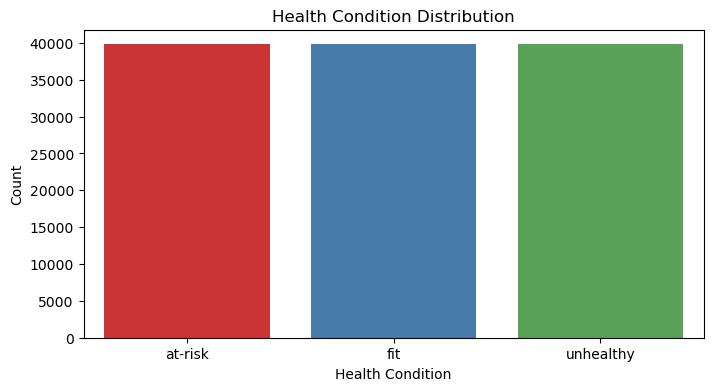

In [469]:
plt.figure(figsize=(8,4))
sns.countplot(x=y_train, palette="Set1")
plt.title("Health Condition Distribution")
plt.xlabel("Health Condition")
plt.ylabel("Count")
plt.show()

In [470]:
num_col=x_train.select_dtypes(include=["int","float"]).columns.to_list()
num_col

['id',
 'sleep_duration',
 'heart_rate',
 'bmi',
 'calorie_expenditure',
 'step_count',
 'exercise_duration',
 'water_intake']

In [471]:
x_train.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
331897,331897,4.49,72.3,17.70,2464.0,14771.0,51.7,2.24,balanced,low,good,active,yes,other
83230,83230,7.35,78.7,24.19,2754.0,14366.0,34.2,2.66,balanced,medium,good,active,yes,male
219772,219772,9.11,77.9,20.81,2241.0,8101.0,65.8,1.42,non-veg,medium,average,active,yes,other
327034,327034,6.99,79.1,24.50,2147.0,7094.0,41.9,2.06,veg,low,poor,sedentary,no,female
324758,324758,5.97,71.9,23.34,1844.0,1844.0,19.6,2.17,veg,low,poor,sedentary,no,female


In [472]:
#train
#log transformation
for col in num_col:
    x_train[col] = abs(np.log1p(x_train[[col]]))

In [473]:
x_train.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
331897,12.712583,1.702928,4.294561,2.928524,7.809947,9.600489,3.964615,1.175573,balanced,low,good,active,yes,other
83230,11.329375,2.122262,4.378270,3.226447,7.921173,9.572689,3.561046,1.297463,balanced,medium,good,active,yes,male
219772,12.300350,2.313525,4.368181,3.082369,7.715124,8.999866,4.201703,0.883768,non-veg,medium,average,active,yes,other
327034,12.697822,2.078191,4.383276,3.238678,7.672292,8.867146,3.758872,1.118415,veg,low,poor,sedentary,no,female
324758,12.690839,1.941615,4.289089,3.192121,7.520235,7.520235,3.025291,1.153732,veg,low,poor,sedentary,no,female


In [474]:
x_train.isnull().sum()

id                         0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64

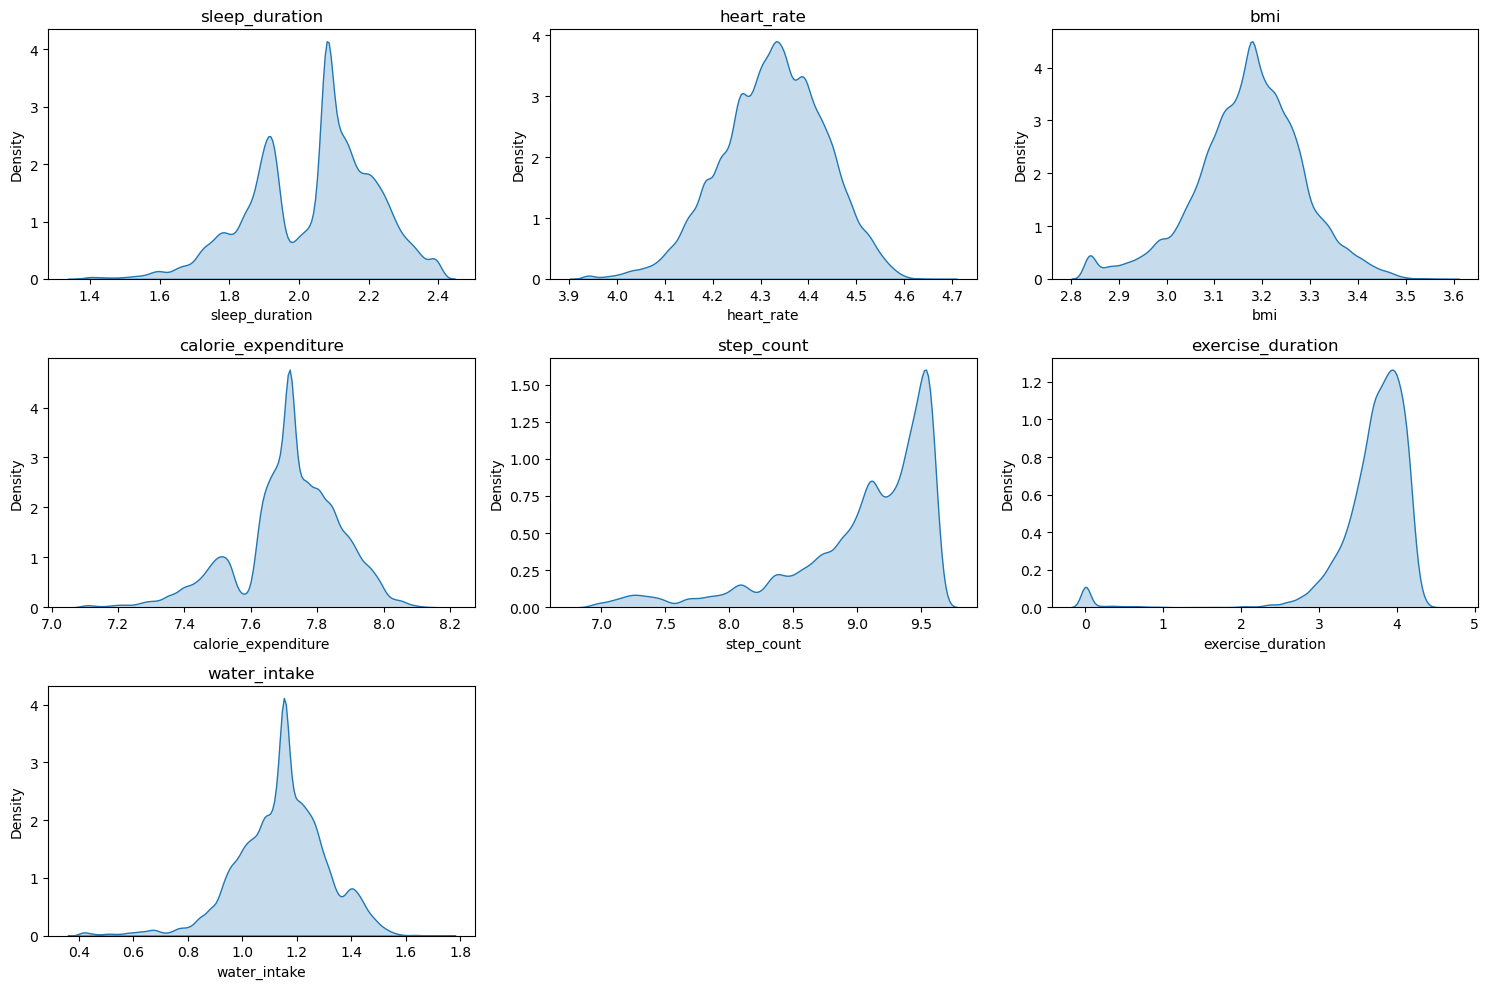

In [475]:
##log transformation transformation data distribution in each columns
plt.figure(figsize=(15, 10))

n = 1
for col in num_cols:
    if col != "id":
        plt.subplot(3, 3, n)
        sns.kdeplot(x_train[col], fill=True)
        plt.title(col)
        n += 1

plt.tight_layout()
plt.show()

In [476]:
##FEATURE ENGINEER

In [477]:
y_train.to_frame()

,health_condition
331897,at-risk
83230,at-risk
219772,at-risk
327034,at-risk
324758,at-risk
...,...
433712,unhealthy
189943,unhealthy
518675,unhealthy
267025,unhealthy


In [478]:
y_train.unique()

array(['at-risk', 'fit', 'unhealthy'], dtype=object)

In [479]:
y_train = y_train.map({
    'at-risk': 0,
    'fit': 1,
    'unhealthy': 2
})

In [489]:
def bmi_category(x):
    if x < 18.5:
        return "underweight"
    elif x < 25:
        return "normal"
    elif x < 30:
        return "overweight"
    else:
        return "obese"

train["bmi_category"] = x_train["bmi"].apply(bmi_category)
test["bmi_category"] = test["bmi"].apply(bmi_category)

In [481]:
x_train["calorie_per_min"] = np.where(
    x_train["exercise_duration"] != 0,
    x_train["calorie_expenditure"] / x_train["exercise_duration"],
    0
)
test["calorie_per_min"] = np.where(
    test["exercise_duration"] != 0,
    test["calorie_expenditure"] / test["exercise_duration"],
    0
)

In [482]:
import numpy as np

train["steps_per_min"] = np.where(
    train["exercise_duration"] != 0,
    train["step_count"] / train["exercise_duration"],
    0
)

test["steps_per_min"] = np.where(
    test["exercise_duration"] != 0,
    test["step_count"] / test["exercise_duration"],
    0
)

In [483]:
x_train["water_per_bmi"] = (
    x_train["water_intake"] /
    x_train["bmi"]
)

test["water_per_bmi"] = (
    test["water_intake"] /
    test["bmi"]
)

In [484]:
activity = {
    "sedentary":0,
    "moderate":1,
    "active":2
}

stress = {
    "low":2,
    "medium":1,
    "high":0
}

sleep = {
    "poor":0,
    "average":1,
    "good":2
}

x_train["life_score"] = (
    x_train["physical_activity_level"].map(activity)
    + x_train["stress_level"].map(stress)
    + x_train["sleep_quality"].map(sleep)
)

test["life_score"] = (
    test["physical_activity_level"].map(activity)
    + test["stress_level"].map(stress)
    + test["sleep_quality"].map(sleep)
)

In [485]:
x_train.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,calorie_per_min,water_per_bmi,life_score
331897,12.712583,1.702928,4.294561,2.928524,7.809947,9.600489,3.964615,1.175573,balanced,low,good,active,yes,other,1.969913,0.401422,6
83230,11.329375,2.122262,4.378270,3.226447,7.921173,9.572689,3.561046,1.297463,balanced,medium,good,active,yes,male,2.224395,0.402134,5
219772,12.300350,2.313525,4.368181,3.082369,7.715124,8.999866,4.201703,0.883768,non-veg,medium,average,active,yes,other,1.836190,0.286717,4
327034,12.697822,2.078191,4.383276,3.238678,7.672292,8.867146,3.758872,1.118415,veg,low,poor,sedentary,no,female,2.041116,0.345331,2
324758,12.690839,1.941615,4.289089,3.192121,7.520235,7.520235,3.025291,1.153732,veg,low,poor,sedentary,no,female,2.485789,0.361431,2


In [486]:
x_train.isnull().sum()

id                         0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
calorie_per_min            0
water_per_bmi              0
life_score                 0
dtype: int64

In [492]:
le=LabelEncoder()
col=["gender","smoking_alcohol","physical_activity_level","sleep_quality","diet_type","stress_level"]

In [493]:
from sklearn.preprocessing import LabelEncoder

for data in col:
    le = LabelEncoder()
    x_train[data] = le.fit_transform(x_train[data])
    test[data] = le.fit_transform(test[data])

In [494]:
x_train.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,calorie_per_min,water_per_bmi,life_score
331897,12.712583,1.702928,4.294561,2.928524,7.809947,9.600489,3.964615,1.175573,0,1,1,0,2,2,1.969913,0.401422,6
83230,11.329375,2.122262,4.378270,3.226447,7.921173,9.572689,3.561046,1.297463,0,2,1,0,2,1,2.224395,0.402134,5
219772,12.300350,2.313525,4.368181,3.082369,7.715124,8.999866,4.201703,0.883768,1,2,0,0,2,2,1.836190,0.286717,4
327034,12.697822,2.078191,4.383276,3.238678,7.672292,8.867146,3.758872,1.118415,2,1,2,2,0,0,2.041116,0.345331,2
324758,12.690839,1.941615,4.289089,3.192121,7.520235,7.520235,3.025291,1.153732,2,1,2,2,0,0,2.485789,0.361431,2


In [495]:
x_train_df,x_test_df,y_train_df,y_test_df=train_test_split(x_train,y_train,test_size=0.2,random_state=42)

In [498]:
print(x_train_df.describe())

                 id  sleep_duration    heart_rate           bmi  \
count  95527.000000    95527.000000  95527.000000  95527.000000   
mean      12.441961        2.042046      4.325814      3.170701   
std        1.004164        0.174308      0.107274      0.112604   
min        0.000000        1.386294      3.931826      2.833213   
25%       12.050567        1.911023      4.255613      3.107274   
50%       12.752780        2.078191      4.330733      3.177637   
75%       13.156163        2.164472      4.400603      3.242983   
max       13.444573        2.397895      4.679350      3.574590   

       calorie_expenditure    step_count  exercise_duration  water_intake  \
count         95527.000000  95527.000000       95527.000000  95527.000000   
mean              7.718037      9.043156           3.656806      1.145544   
std               0.150994      0.565061           0.634148      0.164053   
min               7.091742      6.912743           0.000000      0.405465   
25%        

In [499]:
def model_train(model,x_train,y_train,x_test,y_test):
  model.fit(x_train,y_train)
  pred_test=model.predict(x_test)
  pred_train=model.predict(x_train)
  print("TEST ACCURACY :",accuracy_score(y_test,pred_test))
  print("TRAIN ACCURACY :",accuracy_score(y_train,pred_train))


In [502]:
model_train(LogisticRegression(max_iter=1000),x_train_df,y_train_df,x_test_df,y_test_df)

TEST ACCURACY : 0.8365296038857717
TRAIN ACCURACY : 0.8390088666031593


In [503]:
model_train(KNeighborsClassifier(),x_train_df,y_train_df,x_test_df,y_test_df)

TEST ACCURACY : 0.8138765597521146
TRAIN ACCURACY : 0.8597569273608509


In [504]:
model_train(DecisionTreeClassifier(random_state=42),x_train_df,y_train_df,x_test_df,y_test_df)

TEST ACCURACY : 0.8616112553387488
TRAIN ACCURACY : 1.0


In [505]:
model_train(RandomForestClassifier(random_state=42),x_train_df,y_train_df,x_test_df,y_test_df)

TEST ACCURACY : 0.9036512854869776
TRAIN ACCURACY : 0.9999685952662598


In [507]:
model_train(CatBoostClassifier(
        verbose=0,
        random_state=42
    ),x_train_df,y_train_df,x_test_df,y_test_df)

TEST ACCURACY : 0.905074951846579
TRAIN ACCURACY : 0.9293602855737122


In [509]:
base_models = [
    ("rf", RandomForestClassifier(random_state=42)),
    ("dt", DecisionTreeClassifier(random_state=42)),
    ("gb", GradientBoostingClassifier(random_state=42)),
    ("xgb", XGBClassifier(eval_metric="mlogloss", random_state=42))]

In [510]:
meta_model = LogisticRegression(max_iter=1000)

In [511]:
model_train(StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
),x_train_df,y_train_df,x_test_df,y_test_df)

TEST ACCURACY : 0.9059542751863328
TRAIN ACCURACY : 0.9605870591560501
